shape chargé : (4372, 53)
numériques : 38 → ['customerid', 'recency', 'frequency', 'monetarytotal', 'monetaryavg', 'monetarystd', 'monetarymin', 'monetarymax', 'totalquantity', 'avgquantitypertransaction', 'minquantity', 'maxquantity', 'customertenuredays', 'firstpurchasedaysago', 'preferreddayofweek', 'preferredhour', 'preferredmonth', 'weekendpurchaseratio', 'avgdaysbetweenpurchases', 'uniqueproducts', 'uniquedescriptions', 'avgproductspertransaction', 'uniquecountries', 'negativequantitycount', 'zeropricecount', 'cancelledtransactions', 'returnratio', 'totaltransactions', 'uniqueinvoices', 'avglinesperinvoice', 'age', 'supportticketscount', 'satisfactionscore', 'churn', 'regyear', 'regmonth', 'regday', 'regweekday']
catégorielles : 15 → ['rfmsegment', 'agecategory', 'spendingcategory', 'customertype', 'favoriteseason', 'preferredtimeofday', 'region', 'loyaltylevel', 'churnriskcategory', 'weekendpreference', 'basketsizecategory', 'productdiversity', 'gender', 'accountstatus', 'countr

C:\Users\chaie\AppData\Local\Temp\ipykernel_10412\387473542.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()


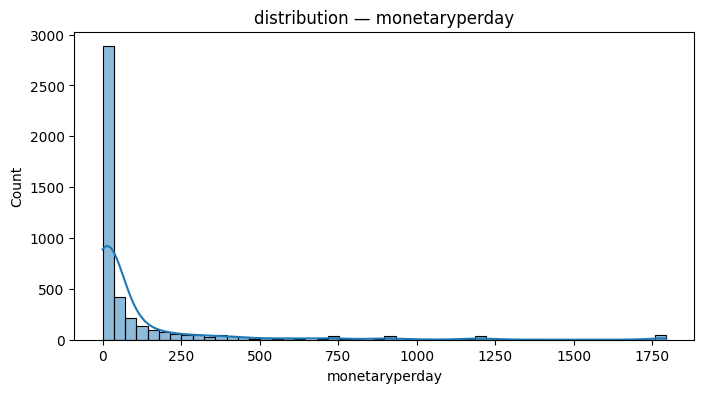

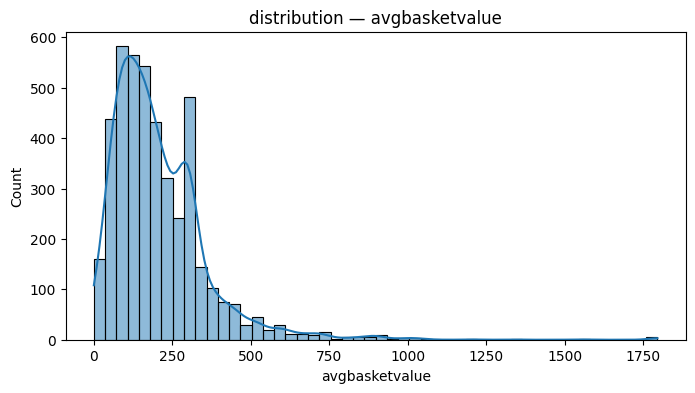

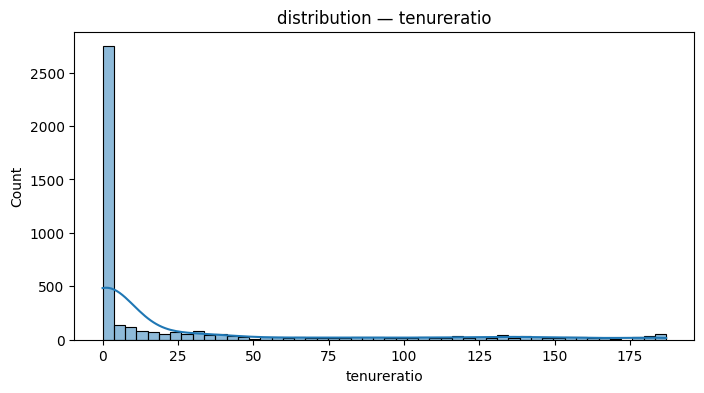

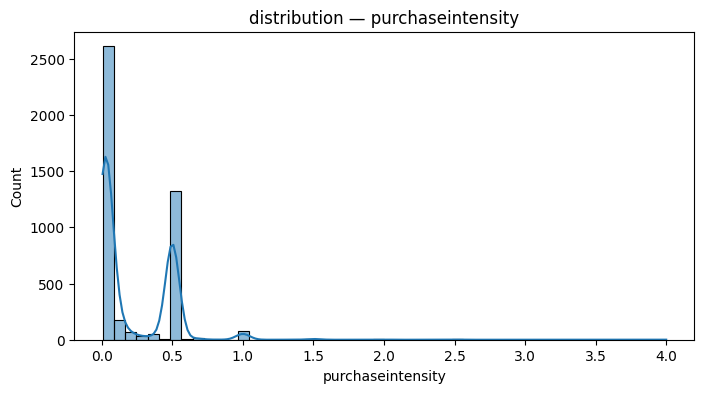

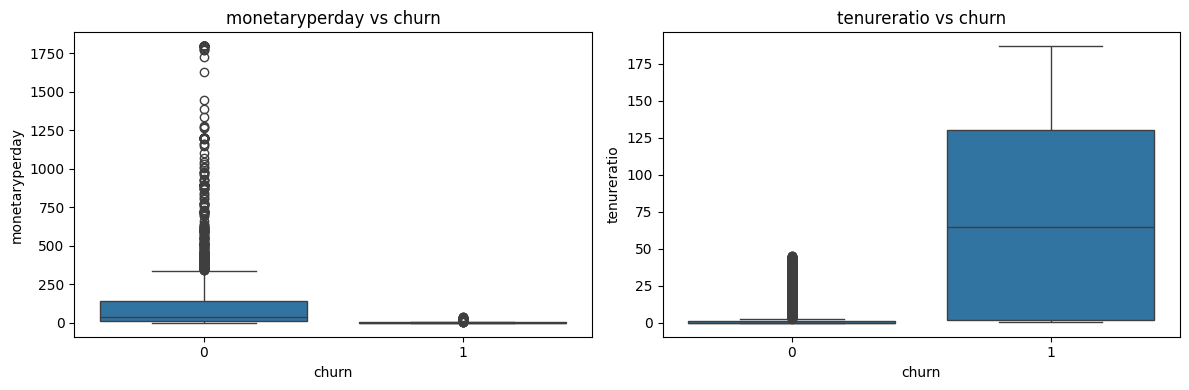

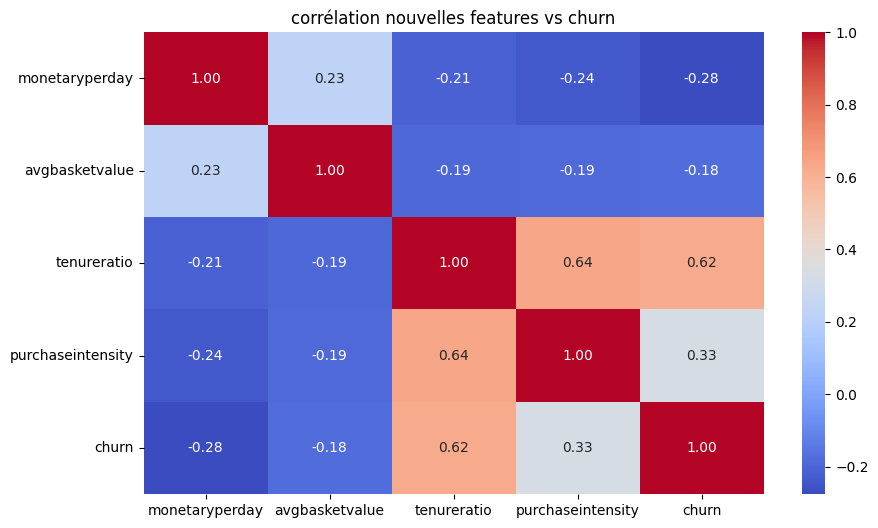

lastloginip déjà supprimée ✅
features log créées : ['monetaryperday_log', 'avgbasketvalue_log', 'returnimpact_log']


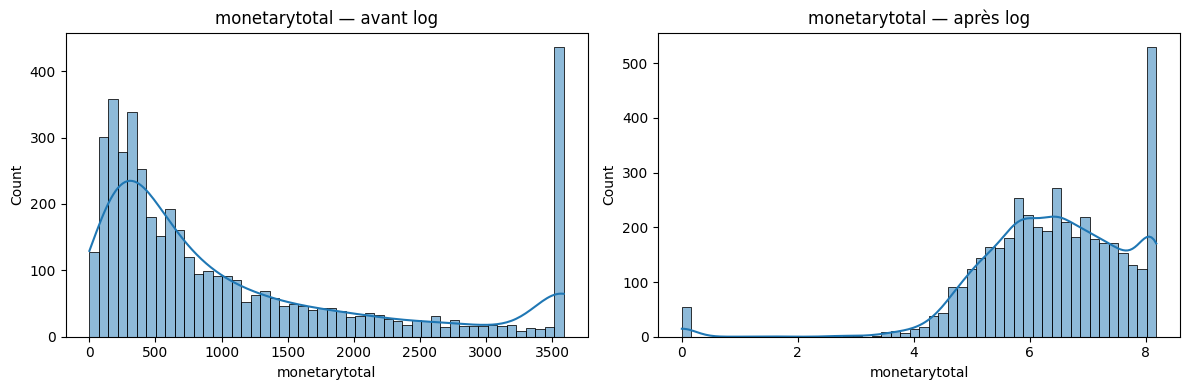

regmonth encodé cycliquement ✅
regweekday encodé cycliquement ✅


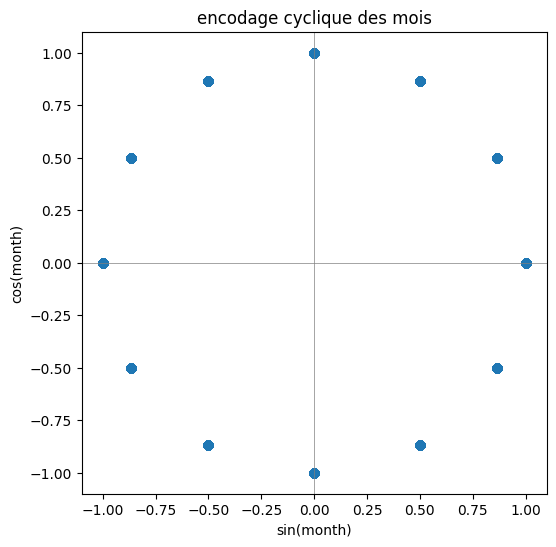

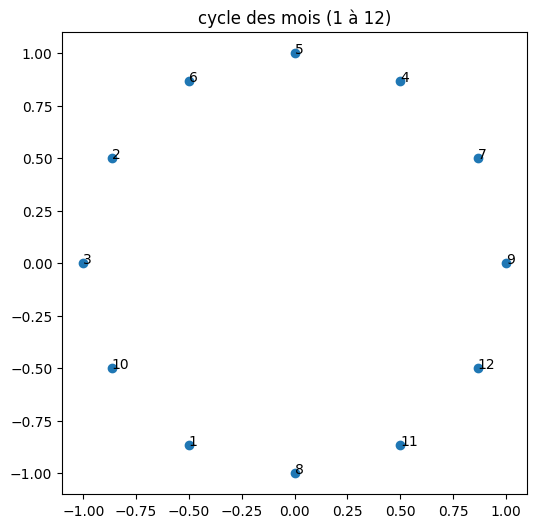

nan restants : 0
shape après nettoyage : (4372, 68)

features corrélées supprimées (13) :
  monetarymin → corrélée avec ['monetarystd']
  monetarymax → corrélée avec ['monetarystd', 'monetarymin']
  minquantity → corrélée avec ['monetarystd', 'monetarymin', 'monetarymax']
  maxquantity → corrélée avec ['monetarystd', 'monetarymin', 'monetarymax', 'minquantity']
  uniquedescriptions → corrélée avec ['uniqueproducts']
  cancelledtransactions → corrélée avec ['negativequantitycount']
  totaltransactions → corrélée avec ['uniqueproducts', 'uniquedescriptions']
  avglinesperinvoice → corrélée avec ['avgproductspertransaction']
  tenureratio → corrélée avec ['recency']
  productdiversityratio → corrélée avec ['avgproductspertransaction', 'avglinesperinvoice']
  engagementscore → corrélée avec ['totalquantity']
  customerscore → corrélée avec ['frequency', 'totalquantity', 'engagementscore']
  customerscorenormalized → corrélée avec ['engagementscorenormalized']

shape après suppression corré

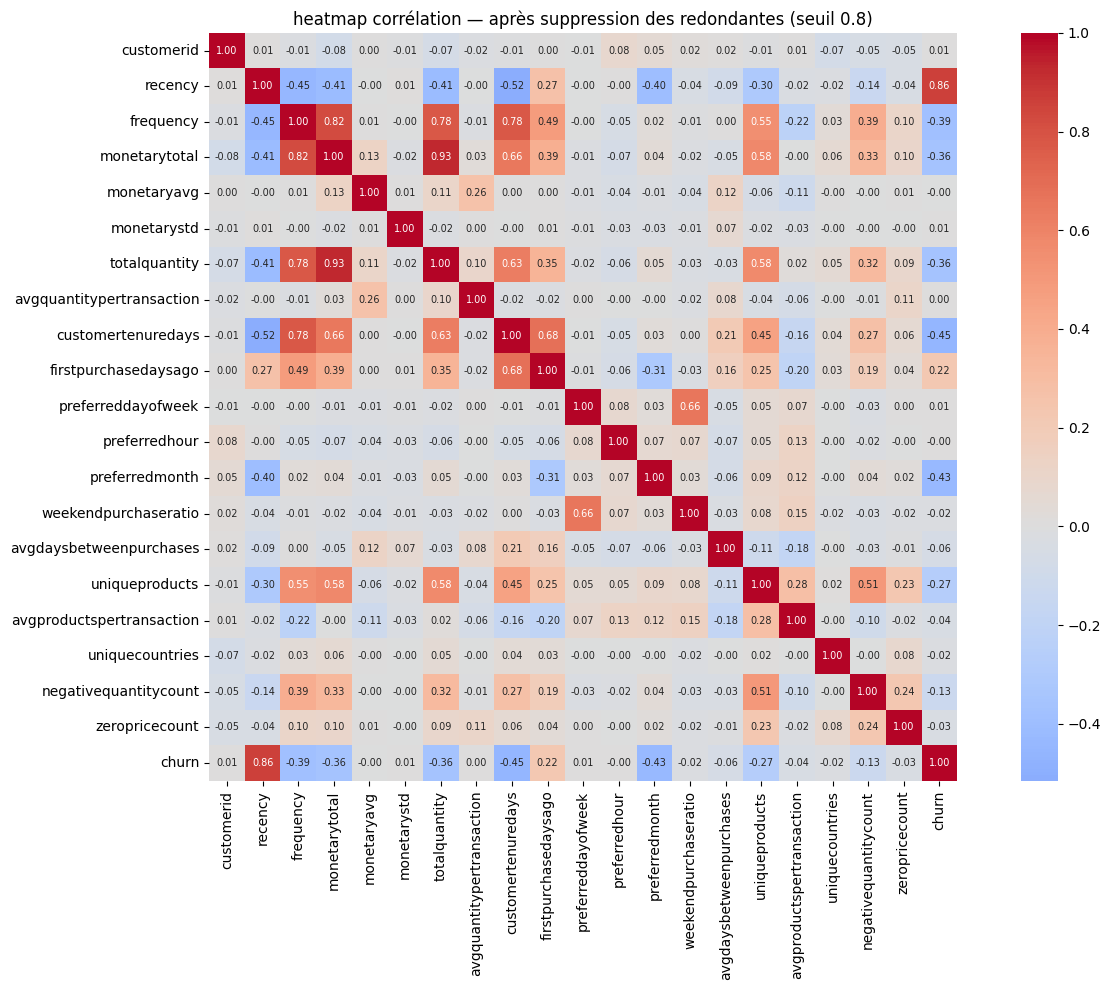

  ordinal encodé : spendingcategory
  ordinal encodé : agecategory
  ordinal encodé : loyaltylevel
  ordinal encodé : rfmsegment
country → target encoding (taux churn moyen par pays) ✅
count    4372.000000
mean        0.332571
std         0.053312
min         0.000000
25%         0.332405
50%         0.332405
75%         0.332405
max         1.000000
Name: country_targetenc, dtype: float64
=== taux de churn par saison ===
favoriteseason
Printemps    0.613164
Hiver        0.517562
Été          0.503896
Automne      0.019231
Name: churn, dtype: float64
  supprimé avant OHE : favoriteseason
  supprimé avant OHE : preferredmonth
  supprimé avant OHE : recency
  supprimé avant OHE : customertenuredays
  supprimé avant OHE : firstpurchasedaysago
  supprimé avant OHE : monetaryperday
  supprimé avant OHE : monetaryperday_log
variables restantes pour one-hot encoding : ['customertype', 'preferredtimeofday', 'region', 'churnriskcategory', 'weekendpreference', 'basketsizecategory', 'productdiver

C:\Users\chaie\AppData\Local\Temp\ipykernel_10412\387473542.py:349: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_remaining = df.select_dtypes(include=['object']).columns.tolist()



top 15 features corrélées avec churn :
churn                       1.000000
customertype_Perdu          0.703052
churnriskcategory_Faible    0.561695
customertype_Occasionnel    0.433675
frequency                   0.389521
monetarytotal               0.361814
totalquantity               0.361717
purchaseintensity           0.328446
churnriskcategory_Moyen     0.319404
customertype_Régulier       0.308989
uniqueproducts              0.269833
avgbasketvalue_log          0.253013
churnriskcategory_Élevé     0.247898
productdiversity_Modéré     0.233466
customertype_Nouveau        0.225844
Name: churn, dtype: float64
✅ toutes les colonnes sont numériques

✅ sauvegardé : ../data/processed/feature_engineering.csv
   4372 clients — 70 features
   52 features initiales → 70 features finales


In [9]:
# %% [markdown]
# # notebook 3 — feature engineering
# - lit     : ../data/processed/step2_cleaning.csv
# - produit : ../data/processed/step3_feature_engineering.csv
#
# ce notebook fait exactement :
#   1. chargement
#   2. feature engineering (nouvelles features)
#   3. extraction lastloginip
#   4. transformations log
#   5. encodage cyclique (mois/jours)
#   6. nettoyage inf/nan
#   7. suppression features corrélées (seuil 0.8) — AVANT get_dummies
#   8. encodage catégoriel (ordinal + target + one-hot)
#   9. suppression colonnes inutiles / fuite
#  10. vérification finale + sauvegarde

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# %%
# chargement
df = pd.read_csv('../data/processed/step2_cleaning.csv')

# tout en minuscules — cohérent dans tout le notebook
df.columns = df.columns.str.lower()

print("shape chargé :", df.shape)
df.head()

# %%
# aperçu colonnes
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print("numériques :", len(num_cols), "→", num_cols)
print("catégorielles :", len(cat_cols), "→", cat_cols)

# %% [markdown]
# # 1. feature engineering — nouvelles features numériques

# %%
# sécuriser les divisions avant de créer les features
df['customertenuredays'] = df['customertenuredays'].replace(0, 1)

# %% [markdown]
# ## 1.1 monetaryperday — dépense par jour (distinguer actifs vs dormants)

# %%
df['monetaryperday'] = df['monetarytotal'] / (df['recency'] + 1)

# %% [markdown]
# ## 1.2 avgbasketvalue — panier moyen (profil d'achat)

# %%
df['avgbasketvalue'] = df['monetarytotal'] / (df['frequency'] + 1)

# %% [markdown]
# ## 1.3 tenureratio — récence / ancienneté (détecter clients qui s'éloignent)

# %%
df['tenureratio'] = df['recency'] / (df['customertenuredays'] + 1)

# %% [markdown]
# ## 1.4 purchaseintensity — intensité d'achat dans le temps

# %%
df['purchaseintensity'] = df['frequency'] / (df['customertenuredays'] + 1)

# %% [markdown]
# ## 1.5 productdiversityratio — diversité des produits achetés

# %%
df['productdiversityratio'] = df['uniqueproducts'] / (df['frequency'] + 1)

# %% [markdown]
# ## 1.6 returnimpact — impact des retours sur la valeur client

# %%
df['returnimpact'] = df['returnratio'] * df['monetarytotal']

# %% [markdown]
# ## 1.7 engagementscore — score d'engagement global

# %%
df['engagementscore'] = df['frequency'] + df['totalquantity'] + df['uniqueproducts']
df['engagementscorenormalized'] = df['engagementscore'] / df['customertenuredays']

# %% [markdown]
# ## 1.8 customerscore — score client pondéré

# %%
df['customerscore'] = (
    df['frequency']     * 0.4 +
    df['monetarytotal'] * 0.4 +
    df['recency']       * 0.2
)
df['customerscorenormalized'] = df['customerscore'] / df['customertenuredays']

# %%
# vérification des nouvelles features
print("nouvelles features créées :")
new_feats = ['monetaryperday','avgbasketvalue','tenureratio','purchaseintensity',
             'productdiversityratio','returnimpact',
             'engagementscore','engagementscorenormalized',
             'customerscore','customerscorenormalized']
df[new_feats].describe()

# %%
# visualisation distributions
features_to_plot = ['monetaryperday','avgbasketvalue','tenureratio','purchaseintensity']

for col in features_to_plot:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"distribution — {col}")
    plt.show()

# %%
# boxplots vs churn pour valider l'utilité
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='churn', y='monetaryperday', data=df, ax=axes[0])
axes[0].set_title("monetaryperday vs churn")
sns.boxplot(x='churn', y='tenureratio', data=df, ax=axes[1])
axes[1].set_title("tenureratio vs churn")
plt.tight_layout()
plt.show()

# %%
# heatmap corrélation des nouvelles features avec churn
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['monetaryperday','avgbasketvalue','tenureratio',
        'purchaseintensity','churn']].corr(),
    annot=True, cmap='coolwarm', fmt=".2f"
)
plt.title("corrélation nouvelles features vs churn")
plt.show()

# %% [markdown]
# # 2. extraction lastloginip → ip_firstoctet + ip_isprivate

# %%
if 'lastloginip' in df.columns:
    # premier octet (type de réseau)
    df['ip_firstoctet'] = df['lastloginip'].str.extract(r'^(\d+)').astype(float)

    # ip privée (1) ou publique (0)
    def is_private(ip):
        try:
            parts = str(ip).split('.')
            first  = int(parts[0])
            second = int(parts[1])
            return int(
                first == 10 or
                (first == 172 and 16 <= second <= 31) or
                (first == 192 and second == 168)
            )
        except:
            return 0

    df['ip_isprivate'] = df['lastloginip'].apply(is_private)
    df.drop(columns=['lastloginip'], inplace=True)
    print("lastloginip → ip_firstoctet + ip_isprivate ✅")
else:
    print("lastloginip déjà supprimée ✅")

# %% [markdown]
# # 3. transformations log (réduire la skewness)

# %%
# clipper à 0 avant le log — éviter nan silencieux sur valeurs négatives
df['monetarytotal']  = df['monetarytotal'].clip(lower=0)
df['monetaryperday'] = df['monetaryperday'].clip(lower=0)
df['avgbasketvalue'] = df['avgbasketvalue'].clip(lower=0)
df['returnimpact']   = df['returnimpact'].clip(lower=0)

# transformation log
log_features = ['monetaryperday', 'avgbasketvalue', 'returnimpact']
for col in log_features:
    df[col + '_log'] = np.log1p(df[col])

print("features log créées :", [c+'_log' for c in log_features])

# %%
# visualisation avant / après
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['monetarytotal'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("monetarytotal — avant log")
sns.histplot(np.log1p(df['monetarytotal']), bins=50, kde=True, ax=axes[1])
axes[1].set_title("monetarytotal — après log")
plt.tight_layout()
plt.show()

# %% [markdown]
# # 4. encodage cyclique (mois et jours)

# %%
if 'regmonth' in df.columns:
    df['regmonth_sin'] = np.sin(2 * np.pi * df['regmonth'] / 12)
    df['regmonth_cos'] = np.cos(2 * np.pi * df['regmonth'] / 12)
    df.drop(columns=['regmonth'], inplace=True)
    print("regmonth encodé cycliquement ✅")

if 'regweekday' in df.columns:
    df['regweekday_sin'] = np.sin(2 * np.pi * df['regweekday'] / 7)
    df['regweekday_cos'] = np.cos(2 * np.pi * df['regweekday'] / 7)
    df.drop(columns=['regweekday'], inplace=True)
    print("regweekday encodé cycliquement ✅")

# %%
# visualisation encodage cyclique
if 'regmonth_sin' in df.columns:
    plt.figure(figsize=(6,6))
    plt.scatter(df['regmonth_sin'], df['regmonth_cos'], alpha=0.3)
    plt.xlabel("sin(month)")
    plt.ylabel("cos(month)")
    plt.title("encodage cyclique des mois")
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)
    plt.show()

    sample = df[['regmonth_sin','regmonth_cos']].drop_duplicates().head(12)
    plt.figure(figsize=(6,6))
    plt.scatter(sample['regmonth_sin'], sample['regmonth_cos'])
    for i, txt in enumerate(range(1,13)):
        if i < len(sample):
            plt.annotate(txt, (sample.iloc[i,0], sample.iloc[i,1]))
    plt.title("cycle des mois (1 à 12)")
    plt.show()

# %% [markdown]
# # 5. nettoyage final — inf et nan résiduels

# %%
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print("nan restants :", df.isnull().sum().sum())
print("shape après nettoyage :", df.shape)

# %% [markdown]
# # 6. suppression features numériques corrélées
# seuil 0.8 — comme dans le rapport (9 features supprimées)
# ⚠️ obligatoirement AVANT get_dummies

# %%
# exclure la target et l'identifiant
# exclude = ['churn', 'customerid']
exclude = ['churn', 'customerid', 'monetarytotal']
num_only = [c for c in df.select_dtypes(include=['int64','float64']).columns
            if c not in exclude]

# matrice de corrélation — triangle supérieur uniquement
corr_matrix = df[num_only].corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# seuil 0.8 (rapport de ta camarade : 9 features supprimées)
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.8)]
print(f"\nfeatures corrélées supprimées ({len(to_drop_corr)}) :")
for col in to_drop_corr:
    corr_with = upper[col][upper[col] > 0.8].index.tolist()
    print(f"  {col} → corrélée avec {corr_with}")

df.drop(columns=to_drop_corr, inplace=True)
print(f"\nshape après suppression corrélées : {df.shape}")

# %%
# heatmap après suppression — vérification visuelle
num_after = df.select_dtypes(include=['int64','float64']).columns.tolist()
top20 = [c for c in num_after if c != 'churn'][:20]

plt.figure(figsize=(14,10))
sns.heatmap(
    df[top20 + ['churn']].corr(),
    annot=True, fmt=".2f",
    cmap='coolwarm', center=0, square=True,
    annot_kws={"size": 7}
)
plt.title("heatmap corrélation — après suppression des redondantes (seuil 0.8)")
plt.tight_layout()
plt.show()

# %% [markdown]
# # 7. encodage des variables catégorielles
# 3 stratégies comme dans le rapport :
#   - ordinal encoding : variables avec ordre logique
#   - target encoding  : country (37+ valeurs)
#   - one-hot encoding : variables nominales restantes

# %% [markdown]
# ## 7.1 ordinal encoding (variables avec ordre logique)

# %%
ordinal_mappings = {
    'spendingcategory': {'low': 0, 'medium': 1, 'high': 2, 'vip': 3},
    'agecategory':      {'18-24': 0, '25-34': 1, '35-44': 2,
                         '45-54': 3, '55-64': 4, '65+': 5, 'inconnu': -1},
    'loyaltylevel':     {'nouveau': 0, 'jeune': 1, 'établi': 2,
                         'ancien': 3, 'inconnu': -1},
    'churnrisk':        {'faible': 0, 'moyen': 1, 'élevé': 2, 'critique': 3},
    'basketsize':       {'petit': 0, 'moyen': 1, 'grand': 2, 'inconnu': -1},
    'preferredtime':    {'nuit': 0, 'matin': 1, 'midi': 2,
                         'après-midi': 3, 'soir': 4},
    'rfmsegment':       {'dormants': 0, 'potentiels': 1,
                         'fidèles': 2, 'champions': 3},
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping).fillna(-1).astype(int)
        print(f"  ordinal encodé : {col}")

# %% [markdown]
# ## 7.2 target encoding pour country (37+ valeurs uniques)

# %%
if 'country' in df.columns:
    # taux de churn moyen par pays
    country_churn_rate = df.groupby('country')['churn'].mean()
    df['country_targetenc'] = df['country'].map(country_churn_rate)
    df.drop(columns=['country'], inplace=True)
    print("country → target encoding (taux churn moyen par pays) ✅")
    print(df['country_targetenc'].describe())
print("=== taux de churn par saison ===")
print(df.groupby('favoriteseason')['churn'].mean().sort_values(ascending=False))
# %% [markdown]
# À placer AVANT pd.get_dummies()
cols_a_supprimer_avant_ohe = [
    'favoriteseason',
    'preferredmonth',
    'recency', 'customertenuredays',
    'firstpurchasedaysago',
    'monetaryperday', 'monetaryperday_log',
    'tenureratio',
]

for col in cols_a_supprimer_avant_ohe:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"  supprimé avant OHE : {col}")
# ## 7.3 one-hot encoding — variables nominales restantes

# %%
cat_cols_remaining = df.select_dtypes(include=['object']).columns.tolist()
print("variables restantes pour one-hot encoding :", cat_cols_remaining)

if cat_cols_remaining:
    df = pd.get_dummies(df, columns=cat_cols_remaining, drop_first=True)
    print("one-hot encoding terminé ✅")

print("shape après encodage :", df.shape)

# %% [markdown]
# # 8. suppression colonnes inutiles et fuites de données

# %%
# colonnes inutiles
cols_inutiles = [
    'customerid',
    'engagementscore',           # remplacé par engagementscorenormalized
    'engagementscorenormalized', # supprimé pour éviter multicolinéarité
    'customerscore',             # remplacé par customerscorenormalized
    'newslettersubscribed',      # valeur constante
]

for col in cols_inutiles:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"  supprimé (inutile) : {col}")

# colonnes fuite — révèlent directement le churn
# cols_fuite = [
#     'churnriskcategory',   # indique directement le risque de churn
#     'churnrisk',           # idem
#     'customertype',        # customertype_perdu = client parti
#     'accountstatus_closed' # compte fermé = client parti
# ]

cols_fuite = [
    # fuites métier directes
    'churnriskcategory', 'churnrisk',
    'customertype', 'accountstatus_closed',
    
    # fuites temporelles confirmées
    'recency', 'customertenuredays', 'firstpurchasedaysago',
    'monetaryperday', 'monetaryperday_log',
    'tenureratio',
    
    # leakage confirmé (mois 10-11 = 0% churn)
    'preferredmonth',
    'favoriteseason',
]

for col in cols_fuite:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"  supprimé (fuite) : {col}")

# %% [markdown]
# # 9. vérification finale

print("\n=== taux de churn par mois préféré ===")
# vérifier preferredmonth si encore présent
if 'preferredmonth' in df.columns:
    print(df.groupby('preferredmonth')['churn'].mean().sort_values(ascending=False))
else:
    print("preferredmonth supprimé ✅")
# %%
print("=" * 50)
print(f"shape final         : {df.shape}")
print(f"nan restants        : {df.isnull().sum().sum()}")
print(f"colonnes object     : {df.select_dtypes(include='object').columns.tolist()}")
print(f"features initiales  : 52")
print(f"features finales    : {df.shape[1]}")
print("=" * 50)

# %%
print("\ndistribution churn :")
print(df['churn'].value_counts())
print(f"\ntaux churn : {df['churn'].mean()*100:.1f}%")

# %%
df.describe()

# %%
# top 15 features les plus corrélées avec churn
corr_churn = df.corr(numeric_only=True)['churn'].abs().sort_values(ascending=False)
print("\ntop 15 features corrélées avec churn :")
print(corr_churn.head(15))

# %%
# vérification — aucune colonne object restante
assert df.select_dtypes(include='object').shape[1] == 0, \
    "⚠️ il reste des colonnes non encodées !"
print("✅ toutes les colonnes sont numériques")

# %% [markdown]
# # 10. sauvegarde

# %%
df.to_csv('../data/processed/feature_engineering.csv', index=False)

print(f"\n✅ sauvegardé : ../data/processed/feature_engineering.csv")
print(f"   {df.shape[0]} clients — {df.shape[1]} features")
print(f"   52 features initiales → {df.shape[1]} features finales")